# 12. Successor linkage and regional-reference evaluation

Generated: `2026-08-16T09:13:03`

This notebook is regenerated from the pipeline outputs. It is the reader-facing linkage and evaluation notebook.

## tl;dr

`M_B_text_ranking @ 0.70` is the frozen conservative primary event definition, not a claim of threshold optimality. It was fixed before the Grand Ouest regional reference was consulted, which is why the locked split below can be read as held out. All four algorithms are compared, including `M_D_fellegi_sunter`, scored from the fitted model.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'scripts').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED = PROJECT_ROOT / 'data/processed/boamp'
BENCHMARK = PROCESSED / 'regional_benchmark'

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

dev = load_json(PROCESSED / 'linkage_evaluation_dev.json')
validation = load_json(PROCESSED / 'linkage_evaluation_validation.json')
modeling = load_json(BENCHMARK / 'modeling/modeling_summary.json')
manifest = load_json(BENCHMARK / 'regional_benchmark_manifest.json')


In [2]:
def method_frame(summary):
    rows = []
    for method in summary['methods']:
        metrics = method['unweighted']
        weighted = method.get('design_weighted', {})
        rows.append({
            'method': method['method'],
            'threshold': method['threshold'],
            'accepted_links': metrics['accepted_links'],
            'precision': metrics['precision_at_1'],
            'recall': metrics['recall_at_1'],
            'fpr': metrics['false_positive_rate_on_negatives'],
            'coverage': metrics['coverage'],
            'precision_ci': metrics.get('precision_at_1_interval_95'),
            'recall_ci': metrics.get('recall_at_1_interval_95'),
            'weighted_precision': weighted.get('precision_at_1', {}).get('estimate'),
            'weighted_recall': weighted.get('recall_at_1', {}).get('estimate'),
            'weighted_fpr': weighted.get('false_positive_rate_on_verified_negatives', {}).get('estimate'),
        })
    return pd.DataFrame(rows)

dev_methods = method_frame(dev)
validation_methods = method_frame(validation)
validation_methods


,method,threshold,accepted_links,precision,recall,fpr,coverage,precision_ci,recall_ci,weighted_precision,weighted_recall,weighted_fpr
0,M_A_deterministic,70.0,15,0.5333,0.4444,0.1296,0.2083,"[0.3012, 0.7519]","[0.2456, 0.6628]",0.5292,0.3985,None
1,M_B_text_ranking,70.0,8,0.8750,0.3889,0.0000,0.1111,"[0.5291, 0.9776]","[0.2031, 0.6138]",0.5548,0.3150,None
2,M_C_weighted_gated,70.0,23,0.5217,0.6667,0.1852,0.3194,"[0.3296, 0.7076]","[0.4375, 0.8372]",0.3919,0.6312,None
3,M_D_fellegi_sunter,65.0,5,0.2000,0.0556,0.0185,0.0694,"[0.0362, 0.6245]","[0.0099, 0.2576]",0.0210,0.0061,None


## Reference State

In [3]:
pd.DataFrame([
    {'item': 'reviewed anchors', 'value': manifest['reviewed_anchors']},
    {'item': 'resolved to one episode', 'value': manifest['remap']['resolved_to_current_episodes']},
    {'item': 'pilot usable anchors', 'value': manifest['splits']['dev']['usable_anchors']},
    {'item': 'pilot positive anchors', 'value': manifest['splits']['dev']['positive_anchors']},
    {'item': 'locked usable anchors', 'value': manifest['splits']['validation']['usable_anchors']},
    {'item': 'locked positive anchors', 'value': manifest['splits']['validation']['positive_anchors']},
    {'item': 'candidate recall ceiling', 'value': manifest['candidate_reachability']['candidate_generation_recall_ceiling']},
])

,item,value
0,reviewed anchors,120.000
1,resolved to one episode,112.000
2,pilot usable anchors,16.000
3,pilot positive anchors,5.000
4,locked usable anchors,72.000
5,locked positive anchors,18.000
6,candidate recall ceiling,0.913


## Held-Out Method Comparison On The Locked Split

,method,threshold,accepted_links,precision,precision_ci,recall,recall_ci,fpr,coverage
0,M_A_deterministic,70.0,15,0.5333,"[0.3012, 0.7519]",0.4444,"[0.2456, 0.6628]",0.1296,0.2083
1,M_B_text_ranking,70.0,8,0.8750,"[0.5291, 0.9776]",0.3889,"[0.2031, 0.6138]",0.0000,0.1111
2,M_C_weighted_gated,70.0,23,0.5217,"[0.3296, 0.7076]",0.6667,"[0.4375, 0.8372]",0.1852,0.3194
3,M_D_fellegi_sunter,65.0,5,0.2000,"[0.0362, 0.6245]",0.0556,"[0.0099, 0.2576]",0.0185,0.0694


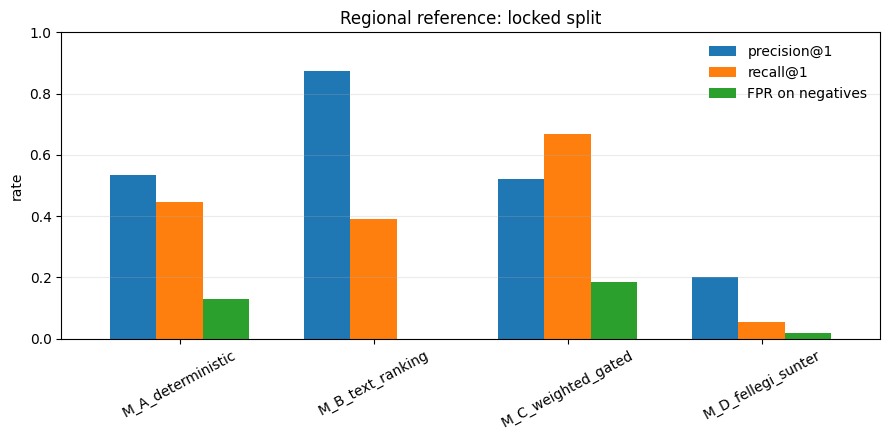

In [4]:
display(validation_methods[['method', 'threshold', 'accepted_links', 'precision', 'precision_ci', 'recall', 'recall_ci', 'fpr', 'coverage']])

ax = validation_methods.set_index('method')[['precision', 'recall', 'fpr']].plot(
    kind='bar', figsize=(9, 4.5), width=0.72
)
ax.set_title('Regional reference: locked split')
ax.set_ylabel('rate')
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.legend(['precision@1', 'recall@1', 'FPR on negatives'], frameon=False)
ax.tick_params(axis='x', rotation=28)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

## Interpretation

`M_C_weighted_gated` recovers more true successors, but its false-positive rate is materially higher. For survival analysis, a false link is more damaging than an abstention because it fabricates both an event and an event time. Thresholds other than `0.70` are carried as sensitivity arms rather than selected from these rows: choosing one now would turn the locked split into a tuning set. On a reference this small the intervals overlap heavily, so read them before separating any two methods. The use of precision-recall evidence for this rare-positive decision follows [Davis and Goadrich (2006)](https://doi.org/10.1145/1143844.1143874) and [Saito and Rehmsmeier (2015)](https://doi.org/10.1371/journal.pone.0118432). Those papers support the diagnostic choice, not this project's numerical results.

## Modeling-Ready Tables

In [5]:
pd.DataFrame(modeling['outputs']).T[[
    'rows', 'anchors', 'primary_positive_pairs', 'positive_anchors'
]]

,rows,anchors,primary_positive_pairs,positive_anchors
dev,5221,16,5,5
validation,20917,69,16,17


In [6]:
feature_columns = pd.Series(modeling['feature_columns'], name='feature')
display(feature_columns.to_frame())
assert 'fs_match_probability' in set(modeling['feature_columns'])


,feature
0,gap_days
1,buyer_name_similarity
2,word_tfidf_similarity
3,char_tfidf_similarity
4,buyer_component
5,text_component
6,cpv_component
7,time_component
8,evidence_components
9,linkage_score


## Caveat

The labels were generated by a single LLM research pass over real BOAMP notices, their official URLs, and wider public sources, dated 2026-08-11, then spot-checked on a subset by the project owner. They are independent of every method scored here, but they were not verified anchor-by-anchor and are not an independent specialist panel. Negatives are corpus-relative: roughly 25 candidates per anchor were considered, so the false-positive rate is conservative by construction rather than a population-wide rate. These are reference-sample estimates, not validated legal-renewal accuracy.